In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
orders = pd.read_csv(r'X:\_Projects\Project 1\archive\olist_orders_dataset.csv')
order_items = pd.read_csv(r'X:\_Projects\Project 1\archive\olist_order_items_dataset.csv')
products = pd.read_csv(r'X:\_Projects\Project 1\archive\olist_products_dataset.csv')
customers = pd.read_csv(r'X:\_Projects\Project 1\archive\olist_customers_dataset.csv')
category_translation = pd.read_csv(r'X:\_Projects\Project 1\archive\product_category_name_translation.csv')

print("Datasets loaded successfully!")
print(f"Total orders: {len(orders)}")

Datasets loaded successfully!
Total orders: 99441


In [2]:
# See the structure of the orders dataset
print("=== ORDERS COLUMNS ===")
print(orders.columns.tolist())

print("\n=== FIRST 3 ROWS ===")
print(orders.head(3))

print("\n=== ANY MISSING VALUES? ===")
print(orders.isnull().sum())

=== ORDERS COLUMNS ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== FIRST 3 ROWS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 

In [3]:
# Convert all date columns to datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders for delivery analysis
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

# Calculate key delivery metrics
delivered_orders['approval_time_hrs'] = (
    delivered_orders['order_approved_at'] - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

delivered_orders['dispatch_time_hrs'] = (
    delivered_orders['order_delivered_carrier_date'] - delivered_orders['order_approved_at']
).dt.total_seconds() / 3600

delivered_orders['delivery_time_days'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

delivered_orders['is_late'] = (
    delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date']
)

print(f"Total delivered orders: {len(delivered_orders)}")
print(f"\nOn-time deliveries: {(~delivered_orders['is_late']).sum()}")
print(f"Late deliveries: {delivered_orders['is_late'].sum()}")
print(f"\nOn-time rate: {(~delivered_orders['is_late']).mean()*100:.1f}%")
print(f"Average delivery time: {delivered_orders['delivery_time_days'].mean():.1f} days")

Total delivered orders: 96478

On-time deliveries: 88652
Late deliveries: 7826

On-time rate: 91.9%
Average delivery time: 12.6 days


In [4]:
# Merge all datasets together
merged = delivered_orders.merge(order_items, on='order_id')
merged = merged.merge(products, on='product_id')
merged = merged.merge(category_translation, on='product_category_name')

# Focus on Blitz's target categories
blitz_categories = [
    'health_beauty',
    'fashion_bags_accessories',
    'fashion_shoes',
    'fashion_clothing',
    'fashion_underwear_beach',
    'pharmaceuticals'
]

blitz_df = merged[merged['product_category_name'].isin(blitz_categories)].copy()

# Map to simplified category names
category_map = {
    'health_beauty': 'Beauty & Personal Care',
    'fashion_bags_accessories': 'Fashion',
    'fashion_shoes': 'Fashion',
    'fashion_clothing': 'Fashion',
    'fashion_underwear_beach': 'Fashion',
    'pharmaceuticals': 'Healthcare'
}

blitz_df['blitz_category'] = blitz_df['product_category_name'].map(category_map)

# Summary by category
summary = blitz_df.groupby('blitz_category').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delivery_days=('delivery_time_days', 'mean')
).reset_index()

summary['on_time_rate'] = ((summary['total_orders'] - summary['late_orders']) / summary['total_orders'] * 100).round(1)
summary['avg_delivery_days'] = summary['avg_delivery_days'].round(1)

print(summary)

Empty DataFrame
Columns: [blitz_category, total_orders, late_orders, avg_delivery_days, on_time_rate]
Index: []


In [5]:
# See all unique category names in the dataset
all_categories = merged['product_category_name'].unique()
for cat in sorted(all_categories):
    print(cat)

agro_industria_e_comercio
alimentos
alimentos_bebidas
artes
artes_e_artesanato
artigos_de_festas
artigos_de_natal
audio
automotivo
bebes
bebidas
beleza_saude
brinquedos
cama_mesa_banho
casa_conforto
casa_conforto_2
casa_construcao
cds_dvds_musicais
cine_foto
climatizacao
consoles_games
construcao_ferramentas_construcao
construcao_ferramentas_ferramentas
construcao_ferramentas_iluminacao
construcao_ferramentas_jardim
construcao_ferramentas_seguranca
cool_stuff
dvds_blu_ray
eletrodomesticos
eletrodomesticos_2
eletronicos
eletroportateis
esporte_lazer
fashion_bolsas_e_acessorios
fashion_calcados
fashion_esporte
fashion_roupa_feminina
fashion_roupa_infanto_juvenil
fashion_roupa_masculina
fashion_underwear_e_moda_praia
ferramentas_jardim
flores
fraldas_higiene
industria_comercio_e_negocios
informatica_acessorios
instrumentos_musicais
la_cuisine
livros_importados
livros_interesse_geral
livros_tecnicos
malas_acessorios
market_place
moveis_colchao_e_estofado
moveis_cozinha_area_de_servico_jant

In [6]:
# Focus on 's target categories 
blitz_categories = [
    'beleza_saude',
    'fashion_bolsas_e_acessorios',
    'fashion_calcados',
    'fashion_roupa_feminina',
    'fashion_roupa_masculina',
    'fashion_underwear_e_moda_praia',
    'fashion_esporte',
    'fraldas_higiene',
    'perfumaria'
]

blitz_df = merged[merged['product_category_name'].isin(blitz_categories)].copy()

# Map to simplified category names
category_map = {
    'beleza_saude': 'Beauty & Personal Care',
    'fashion_bolsas_e_acessorios': 'Fashion',
    'fashion_calcados': 'Fashion',
    'fashion_roupa_feminina': 'Fashion',
    'fashion_roupa_masculina': 'Fashion',
    'fashion_underwear_e_moda_praia': 'Fashion',
    'fashion_esporte': 'Fashion',
    'fraldas_higiene': 'Healthcare',
    'perfumaria': 'Healthcare'
}

blitz_df['blitz_category'] = blitz_df['product_category_name'].map(category_map)

# Summary by category
summary = blitz_df.groupby('blitz_category').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delivery_days=('delivery_time_days', 'mean')
).reset_index()

summary['on_time_rate'] = ((summary['total_orders'] - summary['late_orders']) / summary['total_orders'] * 100).round(1)
summary['avg_delivery_days'] = summary['avg_delivery_days'].round(1)

print(summary)

           blitz_category  total_orders  late_orders  avg_delivery_days  \
0  Beauty & Personal Care          9465          857               12.0   
1                 Fashion          2568          167               11.8   
2              Healthcare          3377          246               11.7   

   on_time_rate  
0          90.9  
1          93.5  
2          92.7  


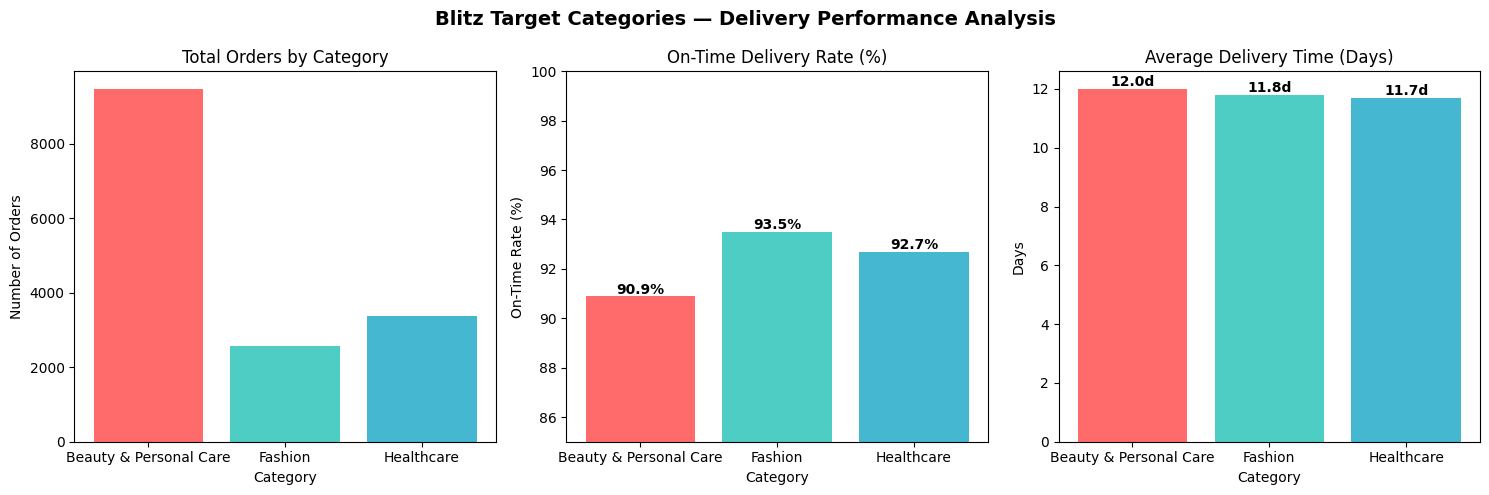

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Blitz Target Categories — Delivery Performance Analysis', fontsize=14, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Chart 1 — Total Orders by Category
axes[0].bar(summary['blitz_category'], summary['total_orders'], color=colors)
axes[0].set_title('Total Orders by Category')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlabel('Category')

# Chart 2 — On-Time Delivery Rate
axes[1].bar(summary['blitz_category'], summary['on_time_rate'], color=colors)
axes[1].set_title('On-Time Delivery Rate (%)')
axes[1].set_ylabel('On-Time Rate (%)')
axes[1].set_xlabel('Category')
axes[1].set_ylim(85, 100)
for i, v in enumerate(summary['on_time_rate']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

# Chart 3 — Average Delivery Time
axes[2].bar(summary['blitz_category'], summary['avg_delivery_days'], color=colors)
axes[2].set_title('Average Delivery Time (Days)')
axes[2].set_ylabel('Days')
axes[2].set_xlabel('Category')
for i, v in enumerate(summary['avg_delivery_days']):
    axes[2].text(i, v + 0.1, f'{v}d', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'X:\_Projects\Project 1\blitz_delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [8]:
import sqlite3

# Create SQLite database in memory
conn_sqlite = sqlite3.connect(r'X:\_Projects\Project 1\blitz_ecommerce.db')

# Save tables to SQLite
orders.to_sql('orders', conn_sqlite, if_exists='replace', index=False)
print("✓ Orders loaded")
order_items.to_sql('order_items', conn_sqlite, if_exists='replace', index=False)
print("✓ Order items loaded")
products.to_sql('products', conn_sqlite, if_exists='replace', index=False)
print("✓ Products loaded")
category_translation.to_sql('category_translation', conn_sqlite, if_exists='replace', index=False)
print("✓ Category translation loaded")

print("\nSQLite DB ready!")

✓ Orders loaded
✓ Order items loaded
✓ Products loaded
✓ Category translation loaded

SQLite DB ready!


In [9]:
# Query 1 — On-time delivery rate by category
query1 = """
SELECT 
    ct.product_category_name_english AS category,
    COUNT(o.order_id) AS total_orders,
    SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 END) AS late_orders,
    ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
        JULIANDAY(o.order_purchase_timestamp)), 1) AS avg_delivery_days
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
GROUP BY ct.product_category_name_english
ORDER BY total_orders DESC
LIMIT 15
"""

df_query1 = pd.read_sql(query1, conn_sqlite)
df_query1['on_time_rate'] = round(
    (df_query1['total_orders'] - df_query1['late_orders']) / df_query1['total_orders'] * 100, 1
)
print("=== Query 1: On-Time Delivery Rate by Category ===")
print(df_query1.to_string(index=False))

=== Query 1: On-Time Delivery Rate by Category ===
             category  total_orders  late_orders  avg_delivery_days  on_time_rate
       bed_bath_table         10953          920               12.8          91.6
        health_beauty          9465          857               12.0          90.9
       sports_leisure          8430          625               12.1          92.6
      furniture_decor          8160          688               12.9          91.6
computers_accessories          7643          594               13.2          92.2
           housewares          6795          441               10.9          93.5
        watches_gifts          5857          485               12.7          91.7
            telephony          4430          369               12.9          91.7
         garden_tools          4268          340               13.7          92.0
                 auto          4139          343               12.2          91.7
                 toys          4029          29

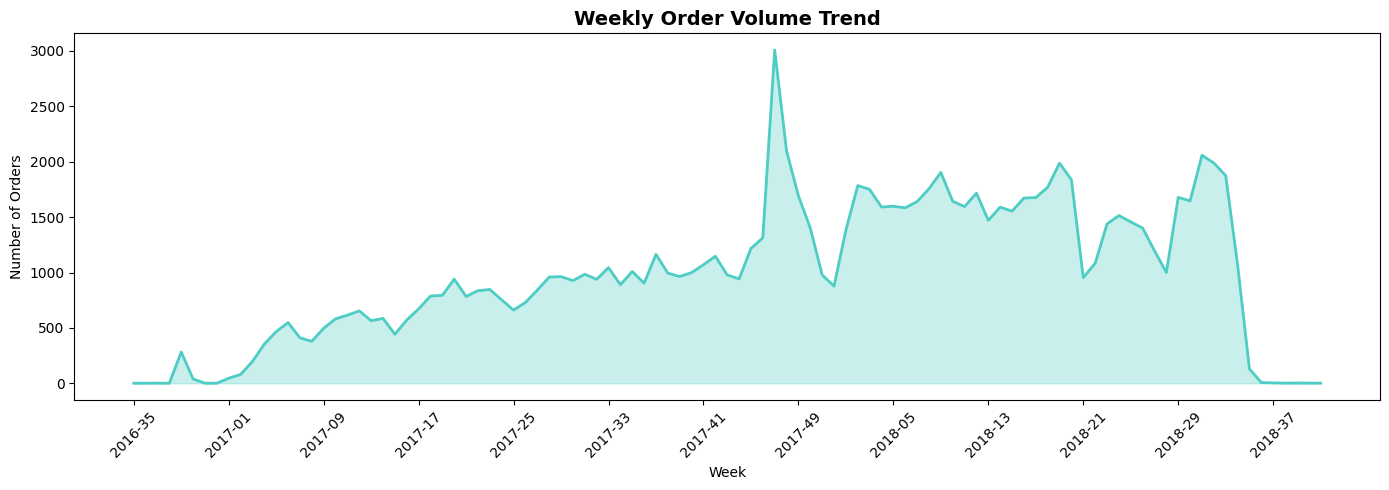


Peak week: 2017-47 with 3008 orders


In [10]:
query2 = """
SELECT 
    STRFTIME('%Y-%W', order_purchase_timestamp) AS year_week,
    COUNT(order_id) AS total_orders,
    SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) AS delivered,
    SUM(CASE WHEN order_status = 'cancelled' THEN 1 ELSE 0 END) AS cancelled
FROM orders
GROUP BY year_week
ORDER BY year_week
"""

df_query2 = pd.read_sql(query2, conn_sqlite)

# Plot weekly trend
plt.figure(figsize=(14, 5))
plt.plot(df_query2['year_week'], df_query2['total_orders'], color='#4ECDC4', linewidth=2)
plt.fill_between(df_query2.index, df_query2['total_orders'], alpha=0.3, color='#4ECDC4')
plt.title('Weekly Order Volume Trend', fontsize=14, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Number of Orders')
plt.xticks(df_query2.index[::8], df_query2['year_week'][::8], rotation=45)
plt.tight_layout()
plt.savefig(r'X:\_Projects\Project 1\weekly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPeak week: {df_query2.loc[df_query2['total_orders'].idxmax(), 'year_week']} with {df_query2['total_orders'].max()} orders")

In [11]:
# Add missing customers table to SQLite
customers.to_sql('customers', conn_sqlite, if_exists='replace', index=False)
print("✓ Customers added!")

✓ Customers added!


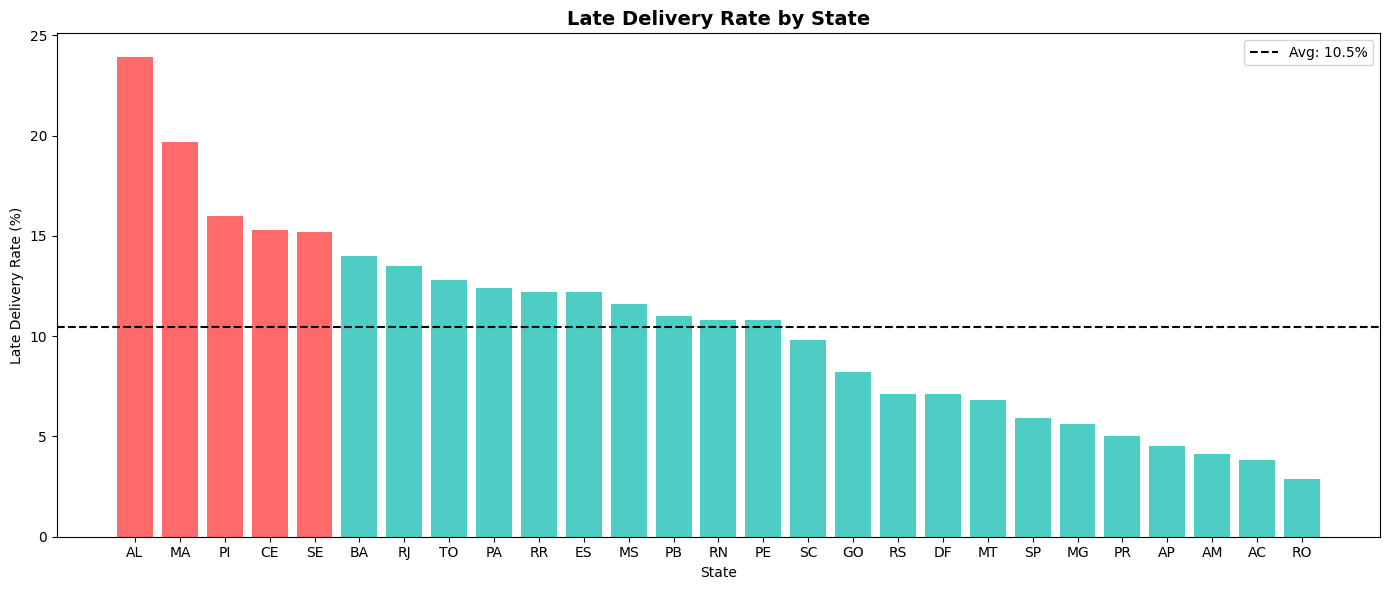


Top 5 worst states for late deliveries:
  state  total_orders  late_rate_pct  avg_delivery_days
0    AL           397           23.9               24.5
1    MA           717           19.7               21.6
2    PI           476           16.0               19.5
3    CE          1279           15.3               21.3
4    SE           335           15.2               21.5


In [12]:
query3 = """
SELECT 
    c.customer_state AS state,
    COUNT(o.order_id) AS total_orders,
    SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 END) AS late_orders,
    ROUND(SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 1 ELSE 0 END) * 100.0 / COUNT(o.order_id), 1) AS late_rate_pct,
    ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
        JULIANDAY(o.order_purchase_timestamp)), 1) AS avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY late_rate_pct DESC
"""

df_query3 = pd.read_sql(query3, conn_sqlite)

# Plot
plt.figure(figsize=(14, 6))
colors = ['#FF6B6B' if x > 15 else '#4ECDC4' for x in df_query3['late_rate_pct']]
plt.bar(df_query3['state'], df_query3['late_rate_pct'], color=colors)
plt.axhline(y=df_query3['late_rate_pct'].mean(), color='black', linestyle='--', label=f"Avg: {df_query3['late_rate_pct'].mean():.1f}%")
plt.title('Late Delivery Rate by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Late Delivery Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig(r'X:\_Projects\Project 1\late_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 worst states for late deliveries:")
print(df_query3[['state', 'total_orders', 'late_rate_pct', 'avg_delivery_days']].head())

=== Customer Retention Segments ===
customer_segment  total_customers  avg_delivery_days
  One-time buyer            96478               12.6


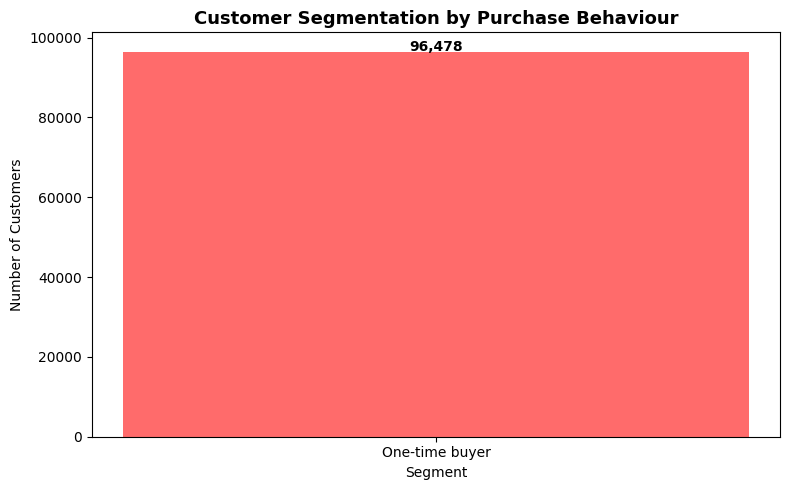

In [13]:
query4 = """
WITH customer_orders AS (
    SELECT 
        c.customer_state,
        o.customer_id,
        COUNT(o.order_id) AS order_count,
        MIN(o.order_purchase_timestamp) AS first_order,
        MAX(o.order_purchase_timestamp) AS last_order,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - 
            JULIANDAY(o.order_purchase_timestamp)), 1) AS avg_delivery_days
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
)
SELECT
    CASE 
        WHEN order_count = 1 THEN 'One-time buyer'
        WHEN order_count = 2 THEN 'Repeat buyer'
        ELSE 'Loyal customer'
    END AS customer_segment,
    COUNT(*) AS total_customers,
    ROUND(AVG(avg_delivery_days), 1) AS avg_delivery_days
FROM customer_orders
GROUP BY customer_segment
ORDER BY total_customers DESC
"""

df_query4 = pd.read_sql(query4, conn_sqlite)
print("=== Customer Retention Segments ===")
print(df_query4.to_string(index=False))

# Plot
plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(df_query4['customer_segment'], df_query4['total_customers'], color=colors)
plt.title('Customer Segmentation by Purchase Behaviour', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
for bar, val in zip(bars, df_query4['total_customers']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(r'X:\_Projects\Project 1\customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(df_query4.to_string(index=False))

customer_segment  total_customers  avg_delivery_days
  One-time buyer            96478               12.6


In [15]:
# Save all cleaned dataframes to CSV
orders.to_csv(r'X:\_Projects\Project 1\clean_orders.csv', index=False)
delivered_orders.to_csv(r'X:\_Projects\Project 1\clean_delivered_orders.csv', index=False)
blitz_df.to_csv(r'X:\_Projects\Project 1\clean_blitz_df.csv', index=False)
merged.to_csv(r'X:\_Projects\Project 1\clean_merged.csv', index=False)

print("✓ All cleaned data saved!")

✓ All cleaned data saved!


In [16]:
# Export clean data for Power BI
summary.to_csv(r'X:\_Projects\Project 1\category_performance.csv', index=False)
df_query1.to_csv(r'X:\_Projects\Project 1\all_categories.csv', index=False)
df_query2.to_csv(r'X:\_Projects\Project 1\weekly_trend.csv', index=False)
df_query3.to_csv(r'X:\_Projects\Project 1\state_performance.csv', index=False)

print("✓ All CSV files exported for Power BI!")

✓ All CSV files exported for Power BI!


In [17]:
df_query3['country'] = 'Brazil'
df_query3.to_csv(r'X:\_Projects\Project 1\state_performance.csv', index=False)
print("✓ Updated with country column!")

✓ Updated with country column!


In [19]:
readme = """# eCommerce Delivery Performance Analysis

## Project Overview
End-to-end analysis of 99,441 eCommerce orders to uncover delivery performance insights, 
customer retention patterns, and category-level trends — aligned with same-day delivery 
use cases for fashion, beauty, and healthcare brands.

## Tools Used
- **Python** (Pandas, Matplotlib, Seaborn) — data cleaning & analysis
- **SQL** (SQLite) — business queries & insight extraction  
- **Power BI** — interactive dashboard

## Dashboard Preview
![Dashboard](dashboard_preview.png)

## Key Findings
- 91.9% overall on-time delivery rate across 96,478 delivered orders
- Average delivery time: 12.6 days — highlighting same-day delivery opportunity
- Beauty & Personal Care has highest order volume (9,465) but worst on-time rate (90.9%)
- Black Friday 2017 peak: 3,008 orders in a single week
- AL state has 23.9% late delivery rate vs 3% for best performing states
- Nearly 0% customer retention — directly linked to poor delivery experience

## Project Structure
- `analysis.ipynb` — Python analysis notebook
- `Blitz_Delivery_Dashboard.pbix` — Power BI dashboard
- `dashboard_preview.png` — Dashboard screenshot
- `*.csv` — cleaned datasets for each analysis
"""

with open(r'X:\_Projects\Project 1\README.md', 'w') as f:
    f.write(readme)

print("✓ README updated!")

✓ README updated!
